# Bab 7 — How to Picture Neural Networks: In Your Head and on Paper

Notebook ini merangkum **Bab 7** buku *Grokking Deep Learning* (Andrew W. Trask, 2019).

Bab ini pendek dan tidak memperkenalkan algoritma baru. Tujuannya adalah **menyederhanakan cara kita membayangkan neural network** agar arsitektur yang lebih rumit (CNN, RNN, LSTM) mudah dipahami. Kuncinya: berpikir dalam **vektor dan matriks**, bukan node satu per satu.

Isi notebook:
1. Saatnya menyederhanakan
2. Correlation summarization
3. Visualisasi yang terlalu rumit vs visualisasi yang disederhanakan
4. Menyederhanakan lebih jauh
5. Visualisasi dengan huruf (notasi aljabar)
6. Menghubungkan variabel: gambar ↔ huruf ↔ kode
7. Pentingnya alat visualisasi

## 0. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

%matplotlib inline
np.random.seed(1)

## 1. Saatnya Menyederhanakan

Sejauh ini kita sudah mempelajari banyak detail kecil: weighted sum, delta, weight_delta, ReLU, backpropagation. Menghafal semuanya satu per satu tidak *scalable*. Trask mengusulkan **satu ide besar** yang merangkum semuanya.

## 2. Correlation Summarization

> **Neural networks seek to find direct and indirect correlation between an input layer and an output layer, which are determined by the input and output datasets, respectively.**

Versi lebih rinci:
- **Local correlation summarization** — setiap set bobot dioptimasi untuk mempelajari bagaimana layer input-nya berkorelasi dengan apa yang diinginkan layer output-nya.
- **Global correlation summarization** — apa yang diinginkan layer sebelumnya ditentukan oleh apa yang diinginkan layer setelahnya, yaitu `delta × bobot` (backpropagation). Hal ini memungkinkan network menemukan **korelasi tidak langsung**.

## 3. Visualisasi yang Terlalu Rumit vs Disederhanakan

Visualisasi lama menggambar **setiap node dan setiap bobot** — cepat menjadi berantakan saat network membesar. Mari bandingkan untuk network Bab 6 (3 → 4 → 1).

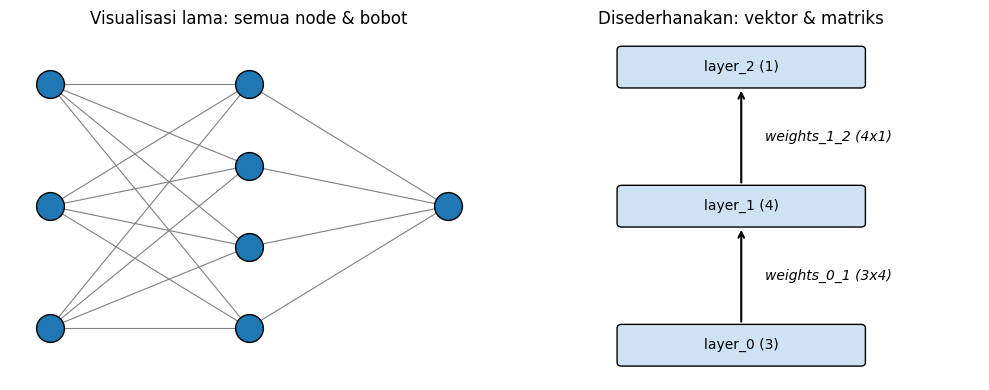

In [2]:
def draw_full_network(ax, sizes, title):
    xs = np.linspace(0, 1, len(sizes))
    coords = []
    for x, n in zip(xs, sizes):
        ys = np.linspace(0.15, 0.85, n) if n > 1 else [0.5]
        coords.append([(x, y) for y in ys])
    for a, b in zip(coords[:-1], coords[1:]):
        for (x1, y1) in a:
            for (x2, y2) in b:
                ax.plot([x1, x2], [y1, y2], color='gray', lw=0.8, zorder=1)
    for layer in coords:
        for (x, y) in layer:
            ax.scatter(x, y, s=400, color='C0', edgecolor='k', zorder=2)
    ax.set_title(title); ax.axis('off'); ax.set_xlim(-0.1, 1.1); ax.set_ylim(0, 1)

def draw_simplified(ax, names, mats, title):
    n = len(names)
    for i, name in enumerate(names):
        y = 0.1 + i * 0.8 / (n - 1)
        ax.add_patch(FancyBboxPatch((0.25, y - 0.05), 0.5, 0.1, boxstyle='round,pad=0.01',
                                    fc='#cfe2f3', ec='k'))
        ax.text(0.5, y, name, ha='center', va='center')
        if i < n - 1:
            y2 = 0.1 + (i + 1) * 0.8 / (n - 1)
            ax.annotate('', xy=(0.5, y2 - 0.06), xytext=(0.5, y + 0.06),
                        arrowprops=dict(arrowstyle='->', lw=1.5))
            ax.text(0.55, (y + y2) / 2, mats[i], va='center', style='italic')
    ax.set_title(title); ax.axis('off'); ax.set_xlim(0, 1); ax.set_ylim(0, 1)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
draw_full_network(axes[0], [3, 4, 1], 'Visualisasi lama: semua node & bobot')
draw_simplified(axes[1], ['layer_0 (3)', 'layer_1 (4)', 'layer_2 (1)'],
                ['weights_0_1 (3x4)', 'weights_1_2 (4x1)'], 'Disederhanakan: vektor & matriks')
plt.tight_layout(); plt.show()

Pada visualisasi sederhana:
- **Layer = vektor** (digambar sebagai satu kotak/strip).
- **Bobot antar layer = matriks** (digambar sebagai satu panah/kotak).

Semua network bisa dipandang sebagai **susunan vektor dan matriks** — seperti balok LEGO yang bisa disusun ulang.

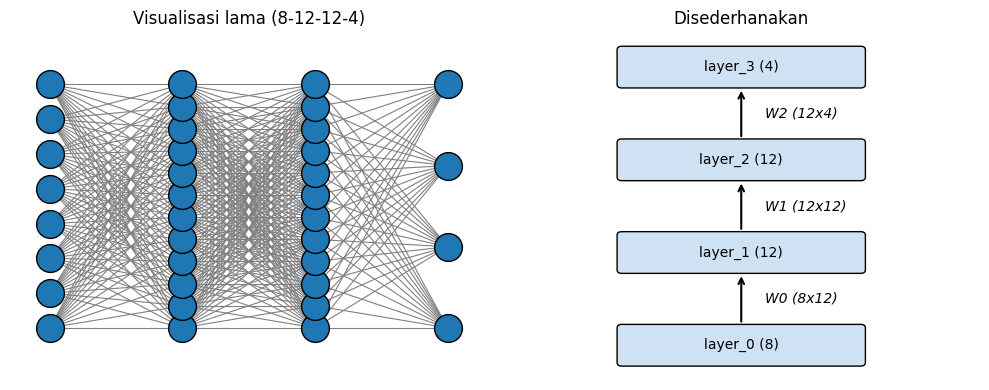

In [3]:
# Network lebih besar: visualisasi lama tidak terbaca, versi sederhana tetap rapi
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
draw_full_network(axes[0], [8, 12, 12, 4], 'Visualisasi lama (8-12-12-4)')
draw_simplified(axes[1], ['layer_0 (8)', 'layer_1 (12)', 'layer_2 (12)', 'layer_3 (4)'],
                ['W0 (8x12)', 'W1 (12x12)', 'W2 (12x4)'], 'Disederhanakan')
plt.tight_layout(); plt.show()

## 4. Menyederhanakan Lebih Jauh

Dimensi matriks sudah ditentukan oleh dimensi layer (`W0` harus `len(layer_0) × len(layer_1)`), sehingga detail matriks pun bisa dihilangkan. Yang tersisa hanyalah **urutan layer** — kita cukup menulis sesuatu seperti `3 → 4 → 1`.

### Mari lihat network ini memprediksi
Prediksi = **mengalirkan vektor** dari bawah ke atas: `layer_0` dikalikan matriks → `layer_1` → ReLU → dikalikan matriks → `layer_2`.

In [4]:
def relu(x):
    return (x > 0) * x

streetlights = np.array([[1, 0, 1], [0, 1, 1], [0, 0, 1], [1, 1, 1]])
walk_stop = np.array([[1, 1, 0, 0]]).T

W0 = 2 * np.random.random((3, 4)) - 1
W1 = 2 * np.random.random((4, 1)) - 1

layer_0 = streetlights[0:1]
layer_1 = relu(layer_0.dot(W0))
layer_2 = layer_1.dot(W1)

for name, v in [('layer_0', layer_0), ('layer_1', layer_1), ('layer_2', layer_2)]:
    print(f'{name}: shape={v.shape}  nilai={v.round(3)}')

layer_0: shape=(1, 3)  nilai=[[1 0 1]]
layer_1: shape=(1, 4)  nilai=[[-0.     0.518 -0.    -0.   ]]
layer_2: shape=(1, 1)  nilai=[[0.392]]


## 5. Visualisasi dengan Huruf (Notasi Aljabar)

Alternatif lain yang sangat ringkas: beri **huruf** untuk setiap vektor dan matriks.

| Simbol | Arti |
|---|---|
| $l_0, l_1, l_2$ | vektor layer (huruf kecil) |
| $W_0, W_1$ | matriks bobot (huruf besar) |

Forward propagation network 3 layer menjadi satu baris:

$$l_2 = \text{relu}(l_0 W_0)\, W_1$$

Network yang lebih dalam tinggal ditambah: $l_3 = \text{relu}(\text{relu}(l_0 W_0) W_1) W_2$.

## 6. Menghubungkan Variabel: Gambar ↔ Huruf ↔ Kode

Ketiga representasi ini **setara**. Trask menekankan kemampuan berpindah bebas di antara ketiganya:

| Gambar | Aljabar | Kode Python |
|---|---|---|
| layer_0 → W0 → layer_1 | $l_1 = \text{relu}(l_0 W_0)$ | `layer_1 = relu(layer_0.dot(weights_0_1))` |
| layer_1 → W1 → layer_2 | $l_2 = l_1 W_1$ | `layer_2 = layer_1.dot(weights_1_2)` |
| backprop ke layer_1 | $\delta_1 = \delta_2 W_1^{\top} \odot \text{relu}'(l_1)$ | `layer_1_delta = layer_2_delta.dot(weights_1_2.T) * relu2deriv(layer_1)` |

In [5]:
# Fungsi forward generik: network berapa pun dalamnya cukup didefinisikan sebagai daftar matriks
def forward(l0, Ws):
    layers = [l0]
    for i, W in enumerate(Ws):
        z = layers[-1].dot(W)
        layers.append(relu(z) if i < len(Ws) - 1 else z)   # ReLU di semua hidden layer
    return layers

sizes = [3, 4, 4, 1]
Ws = [2 * np.random.random((a, b)) - 1 for a, b in zip(sizes[:-1], sizes[1:])]
for i, l in enumerate(forward(streetlights, Ws)):
    print(f'l{i}: shape {l.shape}')

l0: shape (4, 3)
l1: shape (4, 4)
l2: shape (4, 4)
l3: shape (4, 1)


### Everything side by side
Berikut seluruh siklus **predict → compare → learn** untuk network 3 layer, ditulis ringkas dalam notasi vektor–matriks. Perhatikan betapa pendeknya kode ini dibandingkan versi skalar di Bab 3–5.

In [6]:
np.random.seed(1)
relu2deriv = lambda out: out > 0
W0 = 2 * np.random.random((3, 4)) - 1
W1 = 2 * np.random.random((4, 1)) - 1
alpha = 0.2

for it in range(60):
    for i in range(4):
        l0 = streetlights[i:i + 1]
        l1 = relu(l0.dot(W0))                       # predict
        l2 = l1.dot(W1)
        d2 = l2 - walk_stop[i:i + 1]                 # compare
        d1 = d2.dot(W1.T) * relu2deriv(l1)
        W1 -= alpha * l1.T.dot(d2)                   # learn
        W0 -= alpha * l0.T.dot(d1)

print('Prediksi:', relu(streetlights.dot(W0)).dot(W1).ravel().round(3), '| Target:', walk_stop.ravel())

Prediksi: [1.    0.999 0.003 0.   ] | Target: [1 1 0 0]


## 7. Pentingnya Alat Visualisasi

Visualisasi yang ringkas membuat kita bisa:
- **Membandingkan arsitektur** dengan cepat (berapa layer, ukuran tiap layer).
- **Memahami arsitektur baru** dari paper (CNN, RNN, LSTM, Transformer) yang selalu digambar dengan blok vektor/matriks.
- **Mendesain** network sendiri seperti menyusun LEGO.

Mulai Bab 8, network akan selalu digambarkan dengan notasi ringkas ini.

## Rangkuman Bab 7

- **Correlation summarization**: neural network mencari korelasi langsung & tidak langsung antara layer input dan output.
- **Local**: tiap matriks bobot belajar korelasi antara input-nya dan *apa yang diinginkan* output-nya. **Global**: keinginan layer sebelumnya ditentukan lewat backpropagation (`delta × bobot`).
- Gambarkan network sebagai **vektor (layer) dan matriks (bobot)**, bukan node satu per satu.
- Notasi huruf: $l_2 = \text{relu}(l_0 W_0) W_1$ — setara langsung dengan kode NumPy.
- Kemampuan berpindah antara **gambar ↔ aljabar ↔ kode** adalah kunci memahami arsitektur yang lebih kompleks.